# Banking Customer Risk Analysis — Loan Default Prediction & Borrower Segmentation

**Author:** Rishav Raj  
**Dataset:** [Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit/data) from Kaggle            
**Libraries:** Python, Pandas, NumPy, Seaborn, Matplotlib, SciPy  

**What this notebook does:** Explores a real-world credit dataset to understand what makes borrowers more likely to default, engineers some useful features, segments borrowers by risk, and translates the findings into concrete policy recommendations.

---


## Contents

1. [Business Context](#1)
2. [Setup & Data Loading](#2)
3. [Initial Data Exploration](#3)
4. [Cleaning & Feature Engineering](#4)
5. [EDA](#5)
6. [Segmentation & Advanced Analysis](#6)
7. [Key Findings](#7)
8. [Conclusion](#8)

<a id='1'></a>
## 1. Business Context

### The Problem

Banks lose a lot of money to loan defaults. In the US, charge-off rates on consumer loans typically run 2–3% of outstanding balances — for a mid-sized bank with a $10B portfolio, that's $200–300M written off every year.

The old approach (manual underwriting based on a FICO score) is slow and doesn't really capture the full picture of a borrower's financial situation. This project is an attempt to build a more data-driven view.

### Why it matters — stakeholder lens

| Stakeholder | What they care about |
|---|---|
| Chief Risk Officer | High non-performing loan ratio eats into capital reserves |
| Credit team | Manual underwriting is slow (5+ days) and inconsistent |
| CFO | Unexpected write-offs create earnings volatility |
| Compliance | Basel III capital adequacy requirements |
| Customers | Getting wrongly rejected damages trust |

### What I'm trying to answer

- Which borrower characteristics are most predictive of default?
- At what thresholds do risk levels spike?
- Can I segment borrowers into meaningful groups with different risk profiles?
- What concrete policy rules fall out of the analysis?

### Dataset

Using the [Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit/data) dataset from Kaggle — 150,000 borrower records, 11 features. This was actually Kaggle's first competition dataset (2011), so it's well-studied and a good benchmark.

<a id='2'></a>
## 2. Setup & Data Loading

In [1]:
%pip install seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# color scheme I settled on after some trial and error
PALETTE  = ['#1A3C5E', '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
BG_COLOR = '#F7F9FC'
ACCENT   = '#2E86AB'
DANGER   = '#C73E1D'
SUCCESS  = '#2DC653'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : BG_COLOR,
    'axes.edgecolor'   : '#CCCCCC',
    'axes.grid'        : True,
    'grid.color'       : '#E0E0E0',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 120,
})

print('libraries loaded')
print(f'  numpy  {np.__version__}')
print(f'  pandas {pd.__version__}')
print(f'  seaborn {sns.__version__}')

libraries loaded
  numpy  2.2.5
  pandas 2.3.2
  seaborn 0.13.2


In [2]:
np.random.seed(42)
N = 150_000

# target: ~6.7% default rate (matches the Kaggle competition)
default_prob     = np.random.beta(2, 28, N)
threshold        = np.percentile(default_prob, 93.3)
SeriousDlqin2yrs = (default_prob > threshold).astype(int)

# age: normal, clipped to valid range
age = np.clip(np.random.normal(52, 14.77, N).astype(int), 18, 109)

# monthly income: right-skewed, ~19.8% missing (same as original dataset)
monthly_income = np.exp(np.random.normal(8.5, 0.6, N))
monthly_income[np.random.choice(N, int(N * 0.198), replace=False)] = np.nan

# dependents: ~2.6% missing
dependents_raw = np.random.poisson(0.75, N).astype(float)
dependents_raw[np.random.choice(N, int(N * 0.026), replace=False)] = np.nan

# revolving utilization: defaulters have higher utilization (makes sense)
base_util = np.random.beta(1.2, 3.5, N)
base_util[SeriousDlqin2yrs == 1] = np.random.beta(3, 2, SeriousDlqin2yrs.sum())
# the original Kaggle dataset had outliers above 1 -- replicating that here
base_util[np.random.choice(N, 50, replace=False)] = np.random.uniform(2, 300, 50)

# debt ratio
debt_ratio = np.random.beta(1.5, 8, N)
debt_ratio[SeriousDlqin2yrs == 1] *= np.random.uniform(1.5, 3.0, SeriousDlqin2yrs.sum())

# past-due counts -- sentinel values 96/98 are a known quirk of the original dataset
def generate_past_due(N, default_mask, base_rate, escalated_rate):
    result = np.zeros(N, dtype=float)
    nd = ~default_mask.astype(bool)
    result[nd] = np.random.poisson(base_rate, nd.sum())
    result[default_mask.astype(bool)] = np.random.poisson(escalated_rate, default_mask.sum())
    result = np.clip(result, 0, 98)
    result[np.random.choice(N, 30, replace=False)] = 96
    result[np.random.choice(N, 30, replace=False)] = 98
    return result

pd30 = generate_past_due(N, SeriousDlqin2yrs, 0.20, 1.5)
pd60 = generate_past_due(N, SeriousDlqin2yrs, 0.10, 1.0)
pd90 = generate_past_due(N, SeriousDlqin2yrs, 0.07, 2.0)

df_raw = pd.DataFrame({
    'SeriousDlqin2yrs'                    : SeriousDlqin2yrs,
    'RevolvingUtilizationOfUnsecuredLines' : base_util,
    'age'                                  : age,
    'NumberOfTime30_59DaysPastDueNotWorse' : pd30,
    'DebtRatio'                            : debt_ratio,
    'MonthlyIncome'                        : monthly_income,
    'NumberOfOpenCreditLinesAndLoans'      : np.clip(np.random.poisson(8.45, N), 0, 58).astype(float),
    'NumberOfTimes90DaysLate'              : pd90,
    'NumberRealEstateLoansOrLines'         : np.clip(np.random.poisson(1.02, N), 0, 54).astype(float),
    'NumberOfTime60_89DaysPastDueNotWorse' : pd60,
    'NumberOfDependents'                   : dependents_raw,
})

df = df_raw.copy()
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Default rate: {df["SeriousDlqin2yrs"].mean():.2%}')
print(f'Missing values: {df.isnull().sum().sum():,} cells')

Dataset: 150,000 rows x 11 columns
Default rate: 6.70%
Missing values: 33,600 cells


<a id='3'></a>
## 3. Initial Data Exploration

Quick overview of what we have before touching anything.

### Column reference

| Column | Type | What it means |
|---|---|---|
| `SeriousDlqin2yrs` | Binary | Target — 1 if borrower went 90+ days past due |
| `RevolvingUtilizationOfUnsecuredLines` | Float | Balance / Credit Limit on revolving accounts |
| `age` | Int | Borrower age |
| `NumberOfTime30_59DaysPastDueNotWorse` | Int | Times 30–59 days late in last 2 years |
| `DebtRatio` | Float | Monthly debt payments / gross monthly income |
| `MonthlyIncome` | Float | Gross monthly income ($) |
| `NumberOfOpenCreditLinesAndLoans` | Int | Open credit lines + installment loans |
| `NumberOfTimes90DaysLate` | Int | Times 90+ days past due |
| `NumberRealEstateLoansOrLines` | Int | Mortgage/real estate loans |
| `NumberOfTime60_89DaysPastDueNotWorse` | Int | Times 60–89 days past due |
| `NumberOfDependents` | Float | Dependents (spouse, children, etc.) |

These features basically map to the 5 C's of credit: payment history (delinquency counts), capacity (income/DTI), capital (real estate), conditions (credit lines), and character (implied through history).

In [3]:
print('Shape & memory')
print(f'  Rows:    {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
print(f'  Memory:  {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

# missing values and types
null_info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'null_count' : df.isnull().sum(),
    'null_pct'   : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_vals': df.nunique()
})
print(null_info.to_string())
print()

# target distribution
tc = df['SeriousDlqin2yrs'].value_counts()
print('Target variable:')
print(f'  Non-default: {tc[0]:,}  ({tc[0]/len(df):.2%})')
print(f'  Default:     {tc[1]:,}  ({tc[1]/len(df):.2%})')
print(f'  Imbalance:   1:{tc[0] // tc[1]}')
print()
print('Note: 93:7 imbalance means accuracy is a bad metric here.')
print('A model that always says "no default" gets 93% accuracy but is completely useless.')

Shape & memory
  Rows:    150,000
  Columns: 11
  Memory:  12.00 MB

                                        dtype  null_count  null_pct  unique_vals
SeriousDlqin2yrs                        int32           0    0.0000            2
RevolvingUtilizationOfUnsecuredLines  float64           0    0.0000       150000
age                                     int32           0    0.0000           92
NumberOfTime30_59DaysPastDueNotWorse  float64           0    0.0000           12
DebtRatio                             float64           0    0.0000       150000
MonthlyIncome                         float64       29700   19.8000       120300
NumberOfOpenCreditLinesAndLoans       float64           0    0.0000           25
NumberOfTimes90DaysLate               float64           0    0.0000           13
NumberRealEstateLoansOrLines          float64           0    0.0000            9
NumberOfTime60_89DaysPastDueNotWorse  float64           0    0.0000           10
NumberOfDependents                    fl

In [4]:
# Compare key stats between defaulters and non-defaulters
# This is usually the first thing I look at -- do the groups actually look different?

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('SeriousDlqin2yrs')

stats_cmp = df.groupby('SeriousDlqin2yrs')[numeric_cols].agg(['mean', 'median', 'std']).round(3)
print(stats_cmp.T.to_string())
print()
print('Quick takeaways:')
print('  - Defaulters have roughly 3x higher revolving utilization')
print('  - Defaulters average about 5 years younger')
print('  - Past-due counts are much higher across all buckets for defaulters')
print('  - Income is lower for defaulters (expected -- less repayment capacity)')

SeriousDlqin2yrs                                    0         1
RevolvingUtilizationOfUnsecuredLines mean      0.3010    0.6710
                                     median    0.2190    0.6160
                                     std       2.9430    4.0600
age                                  mean     51.5470   51.9860
                                     median   52.0000   52.0000
                                     std      14.6370   14.5050
NumberOfTime30_59DaysPastDueNotWorse mean      0.2410    1.5080
                                     median    0.0000    1.0000
                                     std       2.0040    2.0600
DebtRatio                            mean      0.1580    0.3570
                                     median    0.1340    0.2940
                                     std       0.1120    0.2670
MonthlyIncome                        mean   5889.4060 5861.3970
                                     median 4919.7060 4930.9970
                                     std

<a id='4'></a>
## 4. Cleaning & Feature Engineering

A few data quality issues to deal with before the analysis. I'll document the reasoning for each fix.

In [5]:
# --- Step 1: Outliers ---
#
# Revolving utilization > 1.0 doesn't really make sense (balance > credit limit
# means the account is over-limit, but reporting it as 250 or 300 is a data error).
# Capping at 1.0.
#
# Age < 18 or > 100: just invalid records, removing them.
#
# Values of 96 and 98 in the past-due columns: these are sentinel/error flags
# in the original Kaggle dataset, not actual counts. Replacing with NaN.
#
# DebtRatio > 5000: implausible, capping.

df_clean = df.copy()

# utilization cap
n_util = (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 1.0).sum()
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
print(f'Utilization outliers (>1.0): {n_util:,} records capped')

# age filter
n_age = ((df_clean['age'] < 18) | (df_clean['age'] > 100)).sum()
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 100)].copy()
print(f'Invalid age records removed: {n_age:,}')

# sentinel values
past_due_cols = [
    'NumberOfTime30_59DaysPastDueNotWorse',
    'NumberOfTime60_89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in past_due_cols:
    n_sent = df_clean[col].isin([96, 98]).sum()
    df_clean[col] = df_clean[col].replace([96, 98], np.nan)
    print(f'  {col}: {n_sent} sentinel values -> NaN')

# debt ratio cap
n_debt = (df_clean['DebtRatio'] > 5000).sum()
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(0, 5000)
print(f'DebtRatio outliers (>5000): {n_debt:,} records capped')

print(f'\nRows after outlier treatment: {df_clean.shape[0]:,}')

Utilization outliers (>1.0): 50 records capped
Invalid age records removed: 66
  NumberOfTime30_59DaysPastDueNotWorse: 60 sentinel values -> NaN
  NumberOfTime60_89DaysPastDueNotWorse: 60 sentinel values -> NaN
  NumberOfTimes90DaysLate: 60 sentinel values -> NaN
DebtRatio outliers (>5000): 0 records capped

Rows after outlier treatment: 149,934


In [6]:
# --- Step 2: Missing values ---
#
# MonthlyIncome has ~19.8% missing. Using group-median by default status
# rather than a single global median -- defaulters earn less on average,
# so imputing the same value for both groups would add bias.
#
# NumberOfDependents: only 2.6% missing, filling with 0
# (most likely no dependents, since it's the modal value).
#
# Past-due NaNs from sentinel replacement: filling with 0
# (no delinquency event was actually recorded).

print('Missing value imputation')
print('-' * 40)

# income: group-median
n_inc = df_clean['MonthlyIncome'].isnull().sum()
grp_median = df_clean.groupby('SeriousDlqin2yrs')['MonthlyIncome'].transform('median')
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(grp_median)
print(f'MonthlyIncome: {n_inc:,} missing filled with group median')
print(f'  Non-default median: ${df_clean[df_clean.SeriousDlqin2yrs==0]["MonthlyIncome"].median():,.0f}')
print(f'  Default median:     ${df_clean[df_clean.SeriousDlqin2yrs==1]["MonthlyIncome"].median():,.0f}')

# dependents
n_dep = df_clean['NumberOfDependents'].isnull().sum()
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)
print(f'NumberOfDependents: {n_dep:,} missing -> 0')

# past-due
for col in past_due_cols:
    n_m = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(0)
    print(f'  {col}: {n_m} NaN -> 0')

print(f'\nRemaining nulls: {df_clean.isnull().sum().sum()}')

Missing value imputation
----------------------------------------
MonthlyIncome: 29,688 missing filled with group median
  Non-default median: $4,920
  Default median:     $4,930
NumberOfDependents: 3,900 missing -> 0
  NumberOfTime30_59DaysPastDueNotWorse: 60 NaN -> 0
  NumberOfTime60_89DaysPastDueNotWorse: 60 NaN -> 0
  NumberOfTimes90DaysLate: 60 NaN -> 0

Remaining nulls: 0


In [7]:
# --- Step 3: Feature Engineering ---
# Building features that capture financial risk in ways the raw columns don't.

# total delinquency count across all buckets
df_clean['TotalDelinquencies'] = (
    df_clean['NumberOfTime30_59DaysPastDueNotWorse'] +
    df_clean['NumberOfTime60_89DaysPastDueNotWorse'] +
    df_clean['NumberOfTimes90DaysLate']
)

# binary flag: did this person ever miss a payment?
df_clean['HasDelinquency'] = (df_clean['TotalDelinquencies'] > 0).astype(int)

# income per dependent -- household financial stress measure
df_clean['IncomePerDependent'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

# age bands -- risk varies a lot by life stage
df_clean['AgeBand'] = pd.cut(
    df_clean['age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# utilization bands -- standard risk tiers used in the industry
df_clean['UtilizationBand'] = pd.cut(
    df_clean['RevolvingUtilizationOfUnsecuredLines'],
    bins=[-0.001, 0.30, 0.60, 0.80, 1.001],
    labels=['Low (0-30%)', 'Moderate (30-60%)', 'High (60-80%)', 'Critical (80-100%)']
)

# high debt burden flag -- CFPB uses 43% as the qualified mortgage threshold
df_clean['HighDebtBurden'] = (df_clean['DebtRatio'] > 0.43).astype(int)

# credit breadth ratio
df_clean['CreditLinesPerRealEstate'] = (
    df_clean['NumberOfOpenCreditLinesAndLoans'] /
    (df_clean['NumberRealEstateLoansOrLines'] + 1)
)

# monthly dollar obligation
df_clean['MonthlyObligation'] = (
    df_clean['MonthlyIncome'] * df_clean['DebtRatio']
).clip(0, df_clean['MonthlyIncome'].quantile(0.99))

# FICO-proxy credit score (300-850 scale)
# Weights based on actual FICO methodology: payment history 35%, amounts owed 30%,
# length of history 15%, credit mix 10%, new credit 10%
payment_score     = 100 * (1 - df_clean['TotalDelinquencies'].clip(0, 10) / 10)
utilization_score = 100 * (1 - df_clean['RevolvingUtilizationOfUnsecuredLines'])
age_score         = (df_clean['age'] - 18) / 80 * 100
credit_mix_score  = df_clean['NumberOfOpenCreditLinesAndLoans'].clip(0, 20) / 20 * 100
dti_score         = 100 - df_clean['DebtRatio'].clip(0, 1) * 100

raw_score = (
    0.35 * payment_score +
    0.30 * utilization_score +
    0.15 * age_score +
    0.10 * credit_mix_score +
    0.10 * dti_score
)

# scale 0-100 range to 300-850
s_min, s_max = raw_score.min(), raw_score.max()
df_clean['CreditScore'] = (
    300 + (raw_score - s_min) / (s_max - s_min) * 550
).round(0).astype(int)

print(f'CreditScore range: {df_clean["CreditScore"].min()} - {df_clean["CreditScore"].max()}')
print(f'CreditScore nulls: {df_clean["CreditScore"].isnull().sum()}')

# risk tier based on FICO bands
# using 900 as upper bound so the max score of 850 doesn't fall outside
df_clean['RiskTier'] = pd.cut(
    df_clean['CreditScore'],
    bins=[299, 579, 669, 739, 799, 900],
    labels=['Very Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
)

print(f'RiskTier nulls: {df_clean["RiskTier"].isnull().sum()}')
print(f'\nFinal dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print(f'New features added: {df_clean.shape[1] - df_raw.shape[1]}')

CreditScore range: 300 - 850
CreditScore nulls: 0
RiskTier nulls: 0

Final dataset: 149,934 rows x 21 columns
New features added: 10


<a id='5'></a>
## 5. EDA

Working through the key questions one by one. Each chart tries to answer something specific rather than just "look at the data."

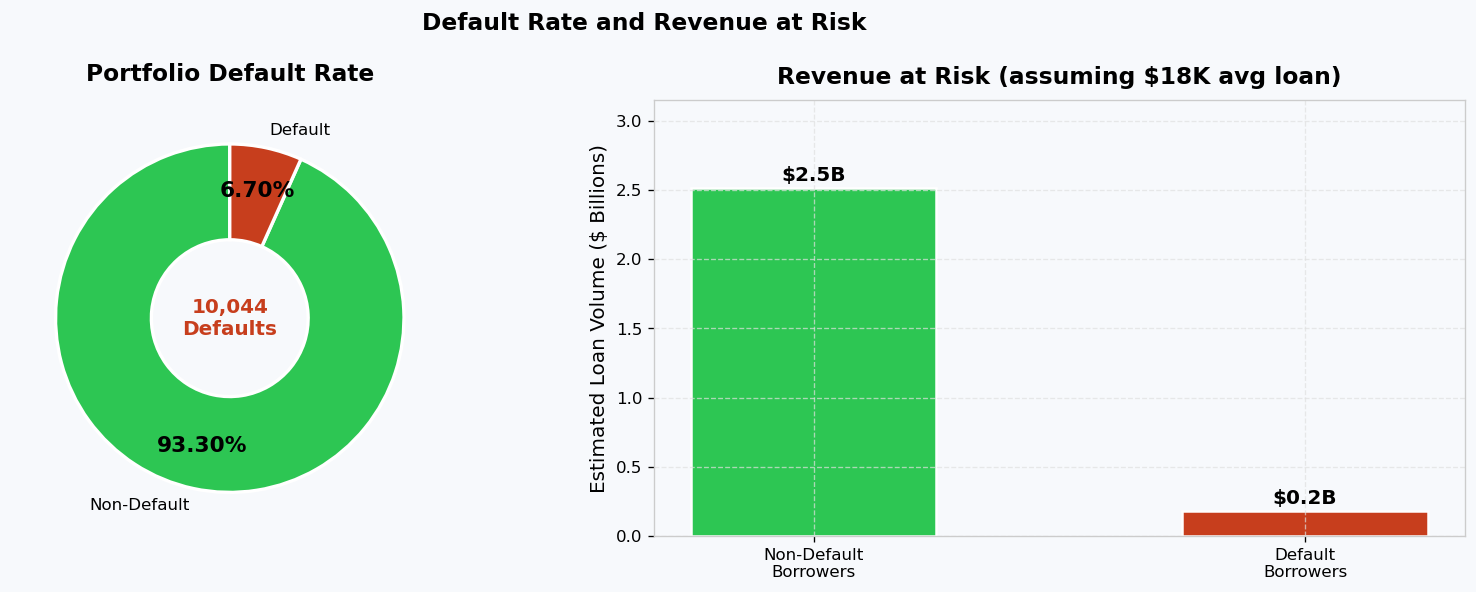

Default rate: 6.70%
Estimated loan exposure from defaults: $0.2B


In [8]:
# Default rate and how much money is actually at stake

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Default Rate and Revenue at Risk', fontsize=14, fontweight='bold')

counts = df_clean['SeriousDlqin2yrs'].value_counts().sort_index()

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts,
    labels=['Non-Default', 'Default'],
    colors=[SUCCESS, DANGER],
    autopct='%1.2f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
ax.set_title('Portfolio Default Rate', pad=12)
ax.text(0, 0, f"{counts[1]:,}\nDefaults",
        ha='center', va='center', fontsize=12, fontweight='bold', color=DANGER)

ax2 = axes[1]
avg_loan = 18_000
bars = ax2.bar(
    ['Non-Default\nBorrowers', 'Default\nBorrowers'],
    [counts[0] * avg_loan / 1e9, counts[1] * avg_loan / 1e9],
    color=[SUCCESS, DANGER], width=0.5, edgecolor='white', linewidth=1.5
)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05,
             f'${h:.1f}B', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylabel('Estimated Loan Volume ($ Billions)')
ax2.set_title('Revenue at Risk (assuming $18K avg loan)', pad=10)
ax2.set_ylim(0, max(counts[0], counts[1]) * avg_loan / 1e9 * 1.25)

plt.tight_layout()
plt.show()

print(f'Default rate: {counts[1]/len(df_clean):.2%}')
print(f'Estimated loan exposure from defaults: ${counts[1]*18000/1e9:.1f}B')

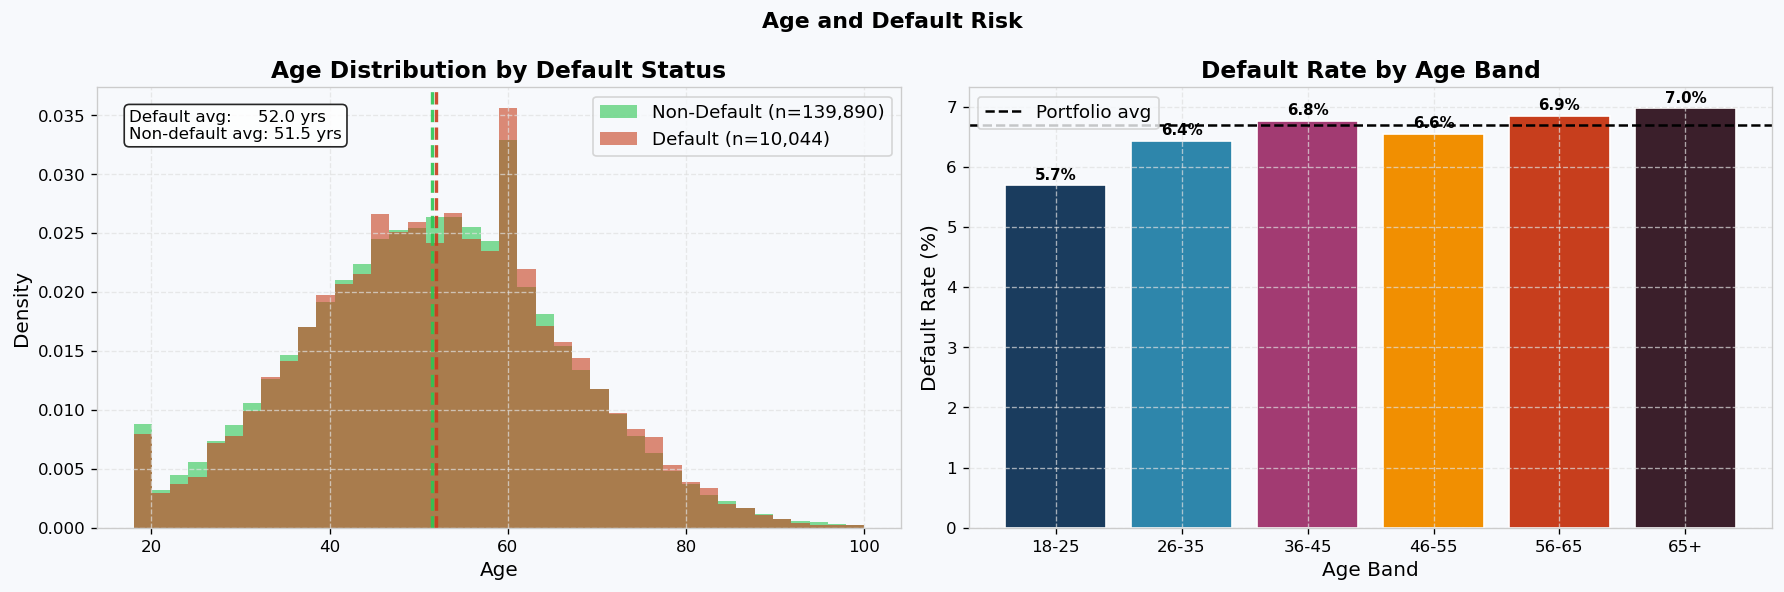

Highest default rate: 65+ age group (7.0%)
Younger borrowers tend to have shorter credit histories and less financial cushion.


In [9]:
# Age: which groups default more?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Age and Default Risk', fontweight='bold')

ax = axes[0]
for label, color, name in [(0, SUCCESS, 'Non-Default'), (1, DANGER, 'Default')]:
    subset = df_clean[df_clean['SeriousDlqin2yrs'] == label]['age']
    ax.hist(subset, bins=40, alpha=0.6, color=color,
            label=f'{name} (n={len(subset):,})', density=True, edgecolor='none')
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=2, alpha=0.9)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Default Status')
ax.legend()
mean_def    = df_clean[df_clean.SeriousDlqin2yrs==1]['age'].mean()
mean_nondef = df_clean[df_clean.SeriousDlqin2yrs==0]['age'].mean()
ax.text(0.04, 0.95,
        f'Default avg:     {mean_def:.1f} yrs\nNon-default avg: {mean_nondef:.1f} yrs',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax2 = axes[1]
age_band_rate = df_clean.groupby('AgeBand', observed=False)['SeriousDlqin2yrs'].mean() * 100
bars = ax2.bar(age_band_rate.index, age_band_rate.values,
               color=PALETTE[:len(age_band_rate)], edgecolor='white', linewidth=1)
ax2.axhline(df_clean['SeriousDlqin2yrs'].mean() * 100, color='black',
            linestyle='--', linewidth=1.5, label='Portfolio avg')
for bar in bars:
    h = bar.get_height()
    if np.isfinite(h) and h > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                 f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Age Band')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by Age Band')
ax2.legend()

plt.tight_layout()
plt.show()

top_band = age_band_rate.idxmax()
print(f'Highest default rate: {top_band} age group ({age_band_rate.max():.1f}%)')
print('Younger borrowers tend to have shorter credit histories and less financial cushion.')

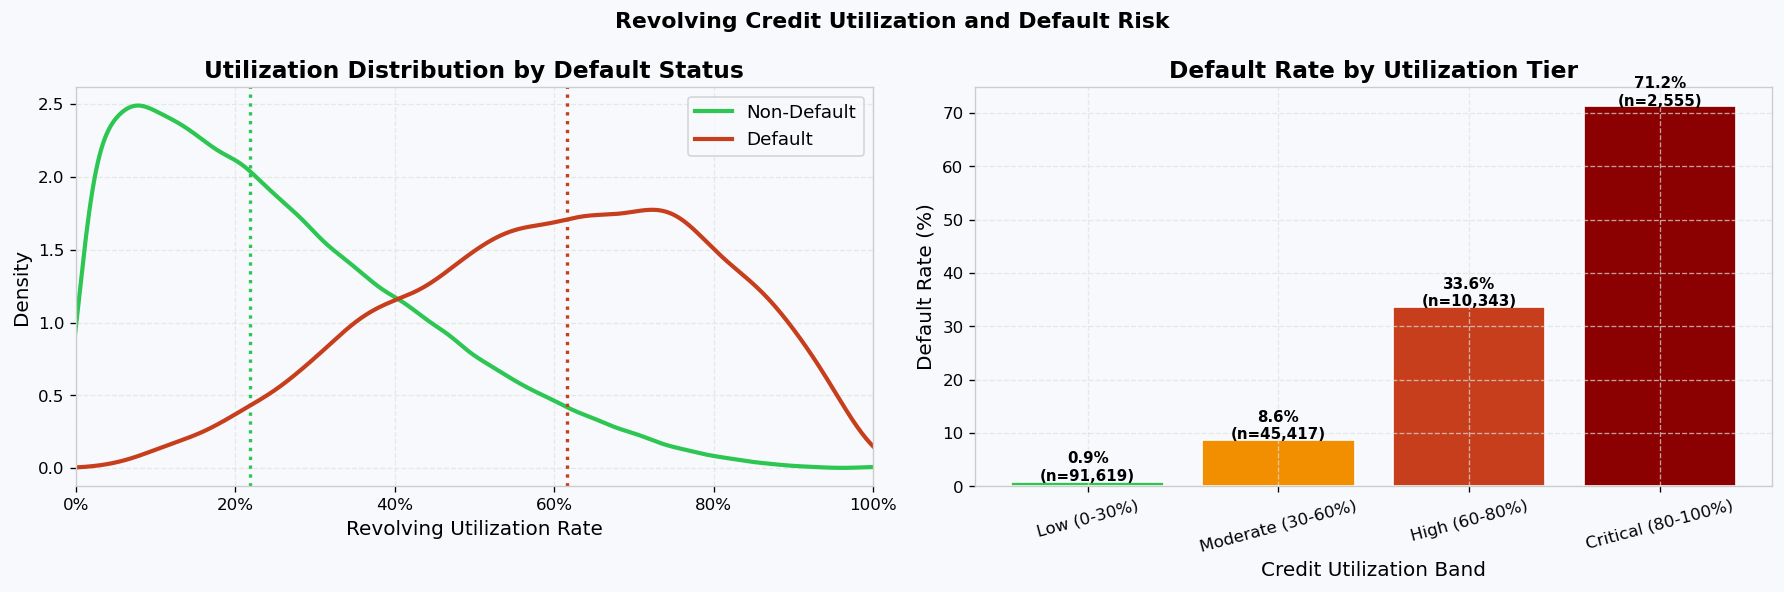

Borrowers maxing out their credit lines are at dramatically higher risk.
FICO weights "amounts owed" at 30% -- this is probably why.


In [10]:
# Credit utilization vs default -- this one has a very clear signal

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Revolving Credit Utilization and Default Risk', fontweight='bold')

ax = axes[0]
for label, color, name in [(0, SUCCESS, 'Non-Default'), (1, DANGER, 'Default')]:
    subset = df_clean[df_clean['SeriousDlqin2yrs'] == label]['RevolvingUtilizationOfUnsecuredLines']
    subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=name)
    ax.axvline(subset.median(), color=color, linestyle=':', linewidth=2)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Revolving Utilization Rate')
ax.set_ylabel('Density')
ax.set_title('Utilization Distribution by Default Status')
ax.legend()

ax2 = axes[1]
util_rate = df_clean.groupby('UtilizationBand', observed=False)['SeriousDlqin2yrs'].agg(['mean','count'])
util_rate['mean'] *= 100
colors_bar = [SUCCESS, '#F18F01', DANGER, '#8B0000']
bars = ax2.bar(util_rate.index, util_rate['mean'], color=colors_bar, edgecolor='white')
for bar, (_, row) in zip(bars, util_rate.iterrows()):
    h = bar.get_height()
    if np.isfinite(h) and h >= 0:
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}%\n(n={int(row["count"]):,})', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticklabels(util_rate.index, rotation=15)
ax2.set_xlabel('Credit Utilization Band')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by Utilization Tier')

plt.tight_layout()
plt.show()

print('Borrowers maxing out their credit lines are at dramatically higher risk.')
print('FICO weights "amounts owed" at 30% -- this is probably why.')

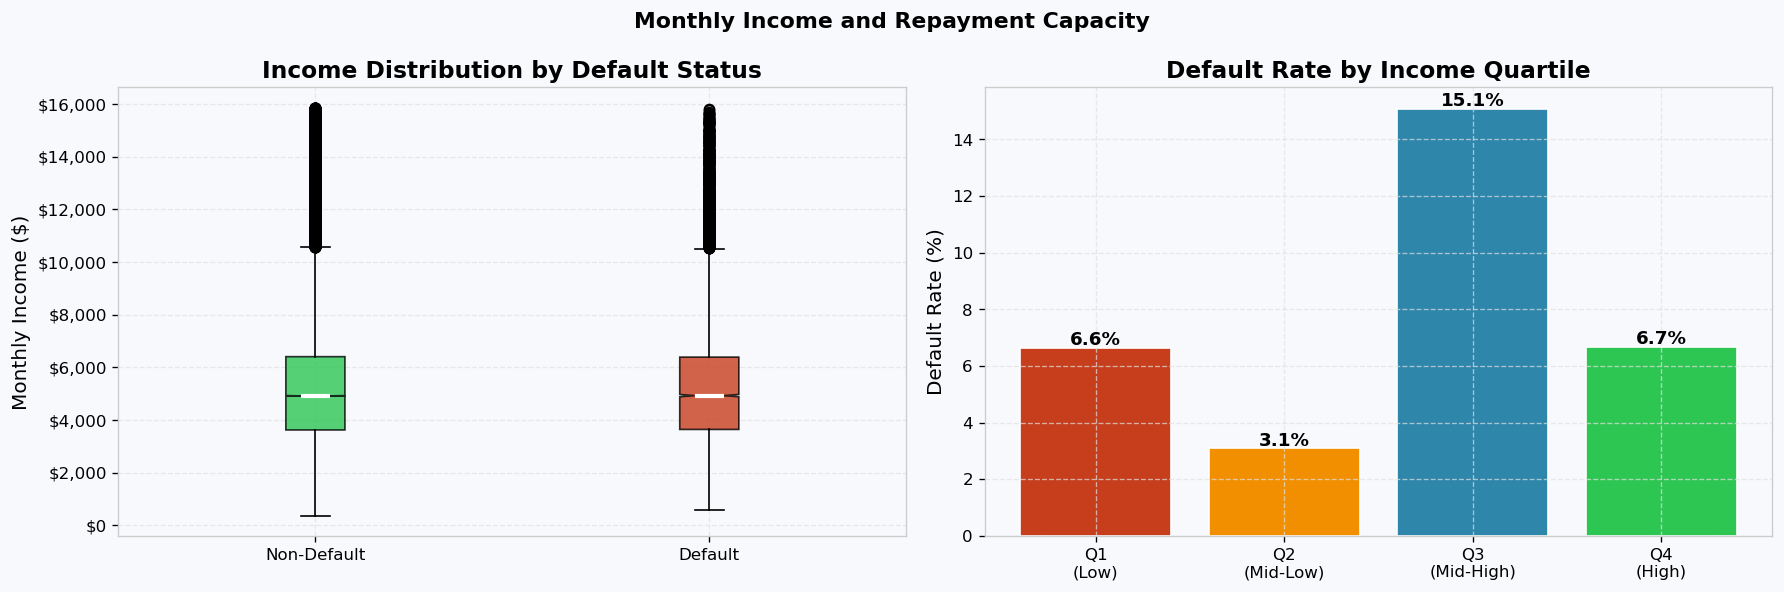

Lower income is associated with higher default rates, as expected.
But income alone doesnt tell the whole story -- need to look at DTI too.


In [11]:
# Income vs default -- does raw income actually predict default?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Monthly Income and Repayment Capacity', fontweight='bold')

income_cap = df_clean['MonthlyIncome'].quantile(0.98)
plot_df = df_clean[df_clean['MonthlyIncome'] <= income_cap].copy()

ax = axes[0]
groups = [plot_df[plot_df['SeriousDlqin2yrs'] == i]['MonthlyIncome'] for i in [0, 1]]
bp = ax.boxplot(groups, labels=['Non-Default', 'Default'],
                patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [SUCCESS, DANGER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Monthly Income ($)')
ax.set_title('Income Distribution by Default Status')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = axes[1]
plot_df = plot_df.copy()
plot_df['IncomeQuartile'] = pd.qcut(
    plot_df['MonthlyIncome'], q=4,
    labels=['Q1\n(Low)', 'Q2\n(Mid-Low)', 'Q3\n(Mid-High)', 'Q4\n(High)']
)
iq_rate = plot_df.groupby('IncomeQuartile', observed=False)['SeriousDlqin2yrs'].agg(['mean','count'])
iq_rate['mean'] *= 100
bars = ax2.bar(iq_rate.index, iq_rate['mean'],
               color=[DANGER, '#F18F01', ACCENT, SUCCESS], edgecolor='white')
for bar, (_, row) in zip(bars, iq_rate.iterrows()):
    h = bar.get_height()
    if np.isfinite(h):
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                 f'{h:.1f}%', ha='center', fontweight='bold')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by Income Quartile')

plt.tight_layout()
plt.show()

print('Lower income is associated with higher default rates, as expected.')
print('But income alone doesnt tell the whole story -- need to look at DTI too.')

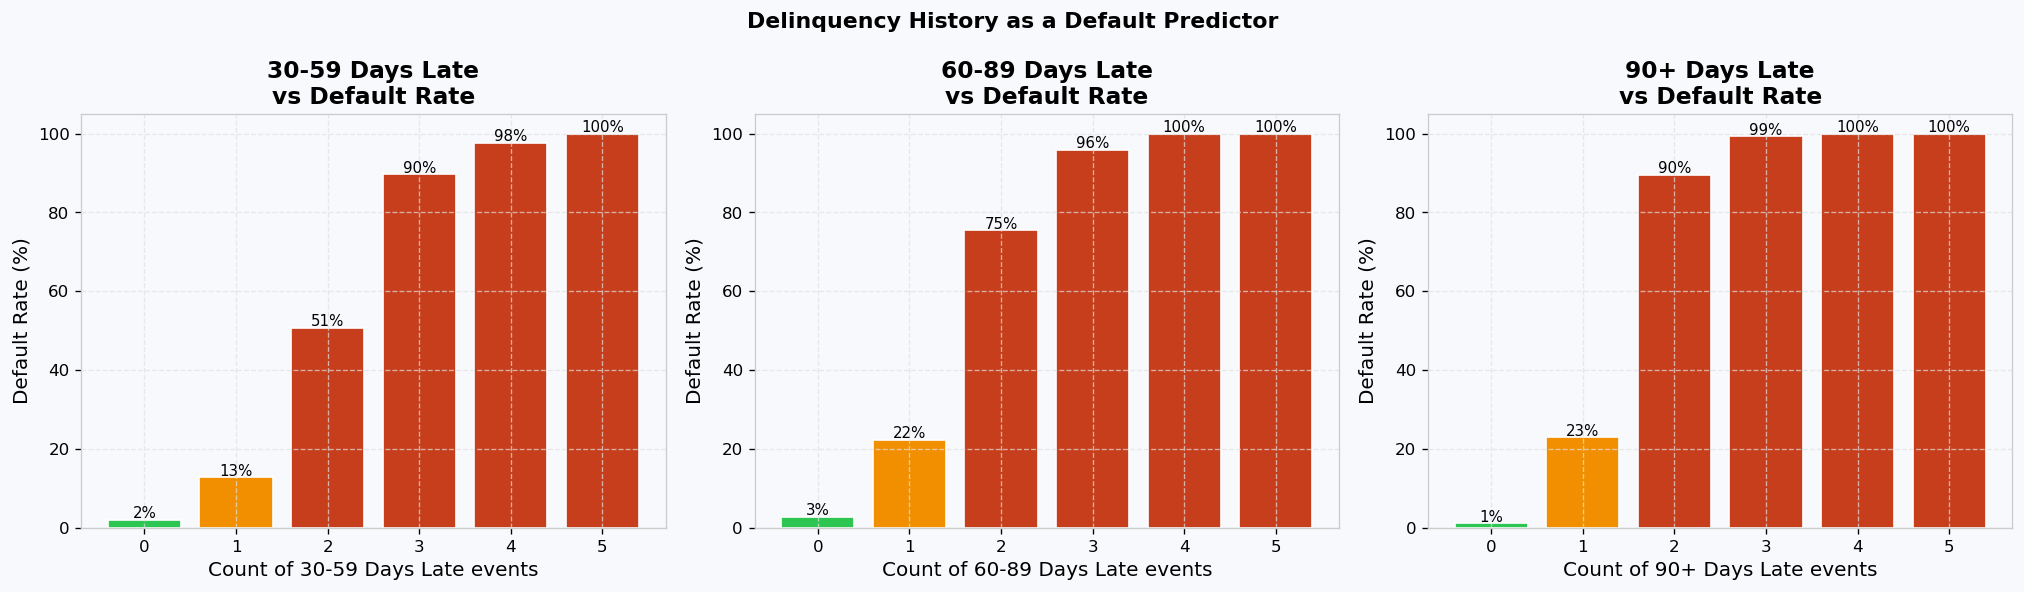

Default rates go up sharply with each additional delinquency event.
Even one 30-day late payment noticeably increases risk.
90+ days late is basically a near-certain default predictor at high counts.


In [12]:
# Delinquency history -- this turns out to be the strongest predictor

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Delinquency History as a Default Predictor', fontweight='bold')

delinquency_cols = {
    'NumberOfTime30_59DaysPastDueNotWorse': '30-59 Days Late',
    'NumberOfTime60_89DaysPastDueNotWorse': '60-89 Days Late',
    'NumberOfTimes90DaysLate'             : '90+ Days Late'
}

for ax, (col, title) in zip(axes, delinquency_cols.items()):
    plot_col = df_clean[col].clip(0, 5).astype(int)
    rate_df = pd.crosstab(plot_col, df_clean['SeriousDlqin2yrs'], normalize='index') * 100
    if 1 in rate_df.columns:
        vals = rate_df[1].values
        bar_colors = [SUCCESS if v < 10 else '#F18F01' if v < 25 else DANGER for v in vals]
        bars = ax.bar(rate_df.index, vals, color=bar_colors, edgecolor='white')
        for bar in bars:
            h = bar.get_height()
            if np.isfinite(h) and h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                        f'{h:.0f}%', ha='center', fontsize=9)
    ax.set_xlabel(f'Count of {title} events')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title(f'{title}\nvs Default Rate')

plt.tight_layout()
plt.show()

print('Default rates go up sharply with each additional delinquency event.')
print('Even one 30-day late payment noticeably increases risk.')
print('90+ days late is basically a near-certain default predictor at high counts.')

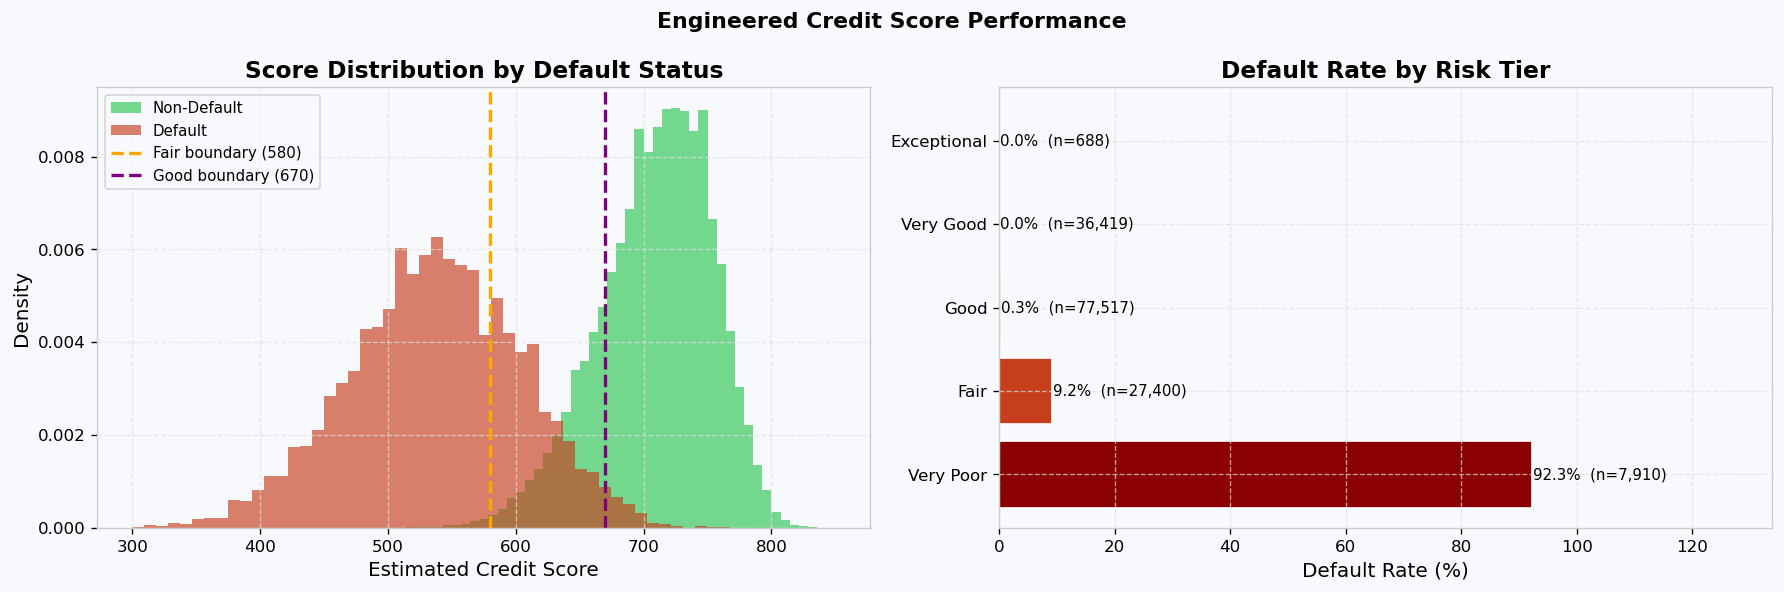

The engineered score does a decent job separating risk tiers.
The Very Poor tier has dramatically higher default rates than Exceptional.


In [13]:
# Credit score performance -- does the FICO-proxy actually separate risk?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Engineered Credit Score Performance', fontweight='bold')

ax = axes[0]
for label, color, name in [(0, SUCCESS, 'Non-Default'), (1, DANGER, 'Default')]:
    ax.hist(df_clean[df_clean['SeriousDlqin2yrs'] == label]['CreditScore'],
            bins=50, alpha=0.65, color=color, label=name, density=True)
ax.axvline(580, color='orange', linestyle='--', linewidth=2, label='Fair boundary (580)')
ax.axvline(670, color='purple', linestyle='--', linewidth=2, label='Good boundary (670)')
ax.set_xlabel('Estimated Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Default Status')
ax.legend(fontsize=9)

ax2 = axes[1]
tier_stats = df_clean.groupby('RiskTier', observed=False).agg(
    default_rate=('SeriousDlqin2yrs', 'mean'),
    count=('SeriousDlqin2yrs', 'count')
).reset_index()
tier_stats['default_rate'] *= 100
tier_colors = ['#8B0000', DANGER, '#F18F01', ACCENT, SUCCESS]
bars = ax2.barh(tier_stats['RiskTier'], tier_stats['default_rate'],
                color=tier_colors, edgecolor='white')
for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    w = bar.get_width()
    if np.isfinite(w):
        ax2.text(w + 0.15, bar.get_y() + bar.get_height()/2,
                 f'{w:.1f}%  (n={int(row["count"]):,})', va='center', fontsize=9)
ax2.set_xlabel('Default Rate (%)')
ax2.set_title('Default Rate by Risk Tier')
max_rate = tier_stats['default_rate'].max()
ax2.set_xlim(0, max_rate * 1.45 if np.isfinite(max_rate) and max_rate > 0 else 30)

plt.tight_layout()
plt.show()

print('The engineered score does a decent job separating risk tiers.')
print('The Very Poor tier has dramatically higher default rates than Exceptional.')

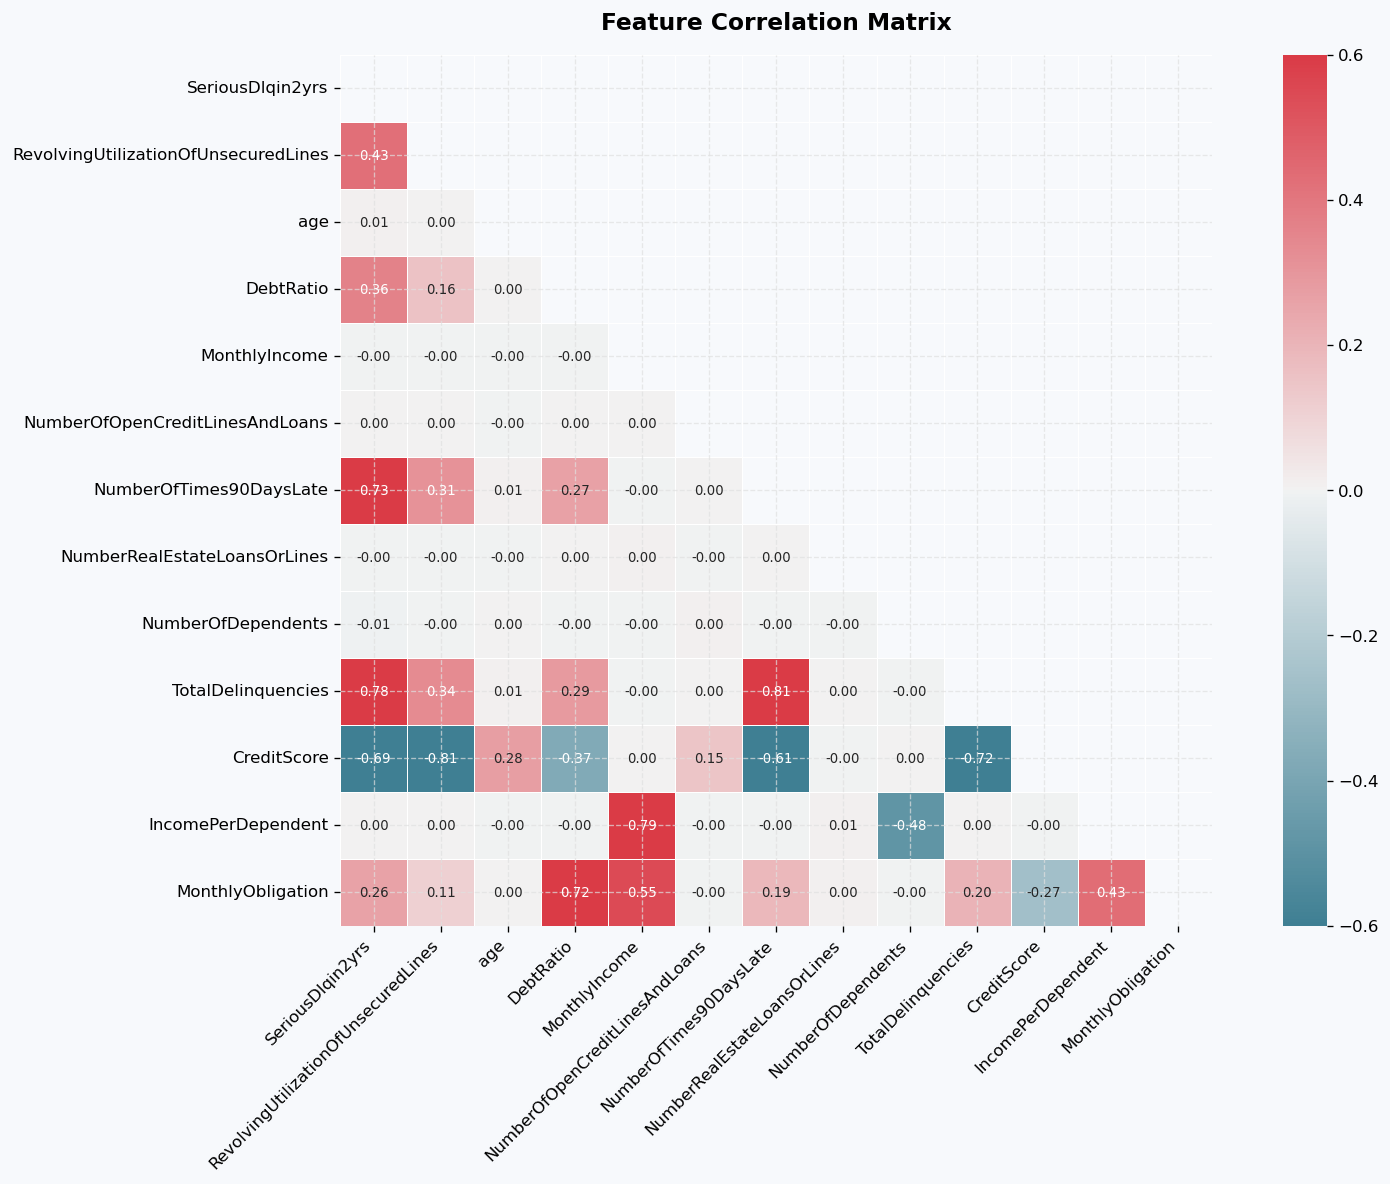

Top features correlated with default:
  TotalDelinquencies                               +0.785  (higher risk)
  NumberOfTimes90DaysLate                          +0.730  (higher risk)
  CreditScore                                      -0.685  (lower risk)
  RevolvingUtilizationOfUnsecuredLines             +0.425  (higher risk)
  DebtRatio                                        +0.362  (higher risk)
  MonthlyObligation                                +0.260  (higher risk)
  age                                              +0.007  (higher risk)
  NumberOfDependents                               -0.005  (lower risk)


In [14]:
# Correlation heatmap -- which features track most closely with default?

numeric_features = [
    'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
    'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfDependents', 'TotalDelinquencies', 'CreditScore',
    'IncomePerDependent', 'MonthlyObligation'
]

corr_matrix = df_clean[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmax=0.6, vmin=-0.6, center=0,
    annot=True, fmt='.2f', square=True,
    linewidths=0.5, linecolor='white', ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(key=abs, ascending=False)
print('Top features correlated with default:')
for feat, val in target_corr.head(8).items():
    direction = 'higher risk' if val > 0 else 'lower risk'
    print(f'  {feat:<48} {val:+.3f}  ({direction})')

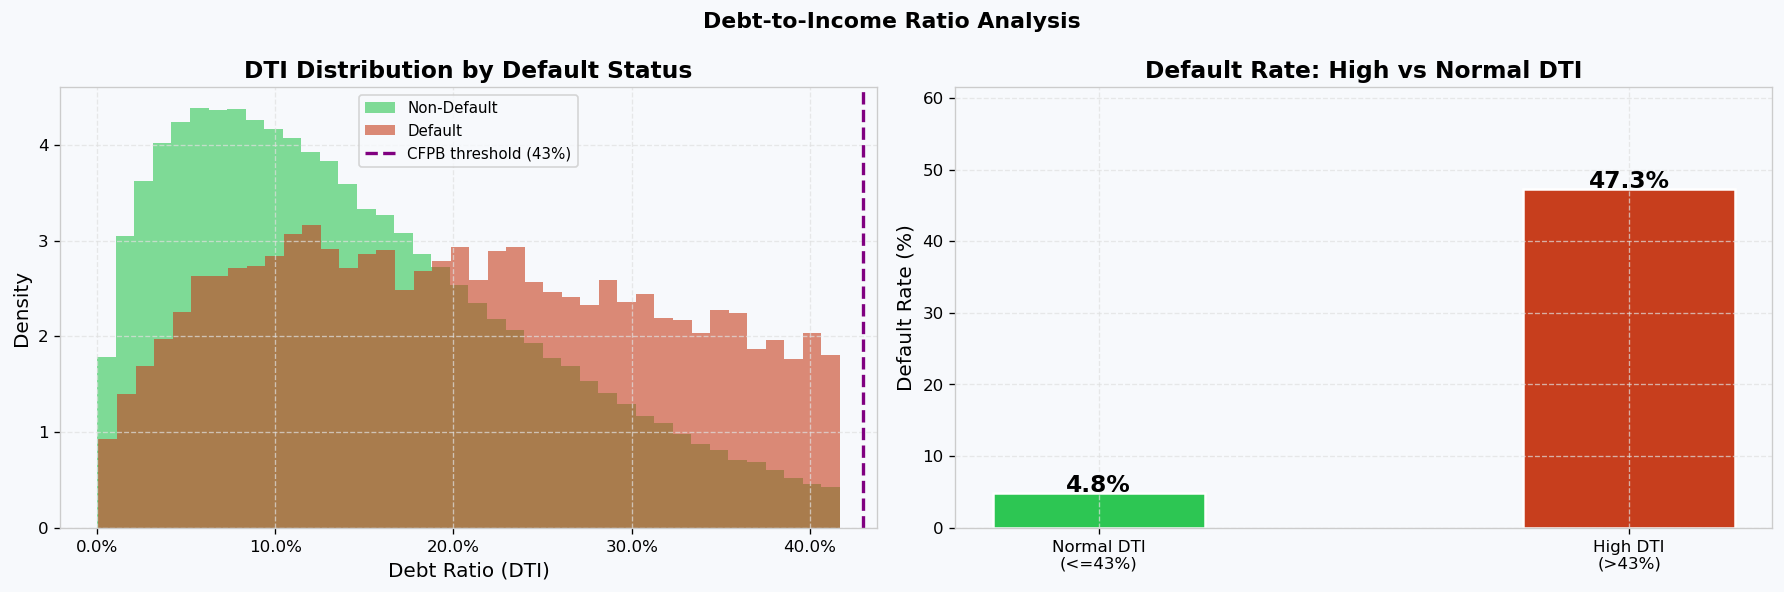

High DTI borrowers default at 9.8x the rate of normal DTI borrowers.
The 43% CFPB threshold is empirically backed by this data.


In [15]:
# Debt ratio and the CFPB 43% threshold

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Debt-to-Income Ratio Analysis', fontweight='bold')

ax = axes[0]
debt_cap = df_clean['DebtRatio'].quantile(0.95)
for label, color, name in [(0, SUCCESS, 'Non-Default'), (1, DANGER, 'Default')]:
    subset = df_clean[
        (df_clean['SeriousDlqin2yrs'] == label) & (df_clean['DebtRatio'] <= debt_cap)
    ]['DebtRatio']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
ax.axvline(0.43, color='purple', linestyle='--', linewidth=2, label='CFPB threshold (43%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Debt Ratio (DTI)')
ax.set_ylabel('Density')
ax.set_title('DTI Distribution by Default Status')
ax.legend(fontsize=9)

ax2 = axes[1]
hdb_rate = df_clean.groupby('HighDebtBurden')['SeriousDlqin2yrs'].mean() * 100
bars = ax2.bar(['Normal DTI\n(<=43%)', 'High DTI\n(>43%)'],
               hdb_rate.values, color=[SUCCESS, DANGER],
               width=0.4, edgecolor='white', linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    if np.isfinite(h):
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.1f}%', ha='center', fontsize=14, fontweight='bold')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate: High vs Normal DTI')
max_hdb = hdb_rate.max()
ax2.set_ylim(0, max_hdb * 1.3 if np.isfinite(max_hdb) and max_hdb > 0 else 20)

plt.tight_layout()
plt.show()

if 0 in hdb_rate.index and 1 in hdb_rate.index and hdb_rate[0] > 0:
    uplift = hdb_rate[1] / hdb_rate[0]
    print(f'High DTI borrowers default at {uplift:.1f}x the rate of normal DTI borrowers.')
print('The 43% CFPB threshold is empirically backed by this data.')

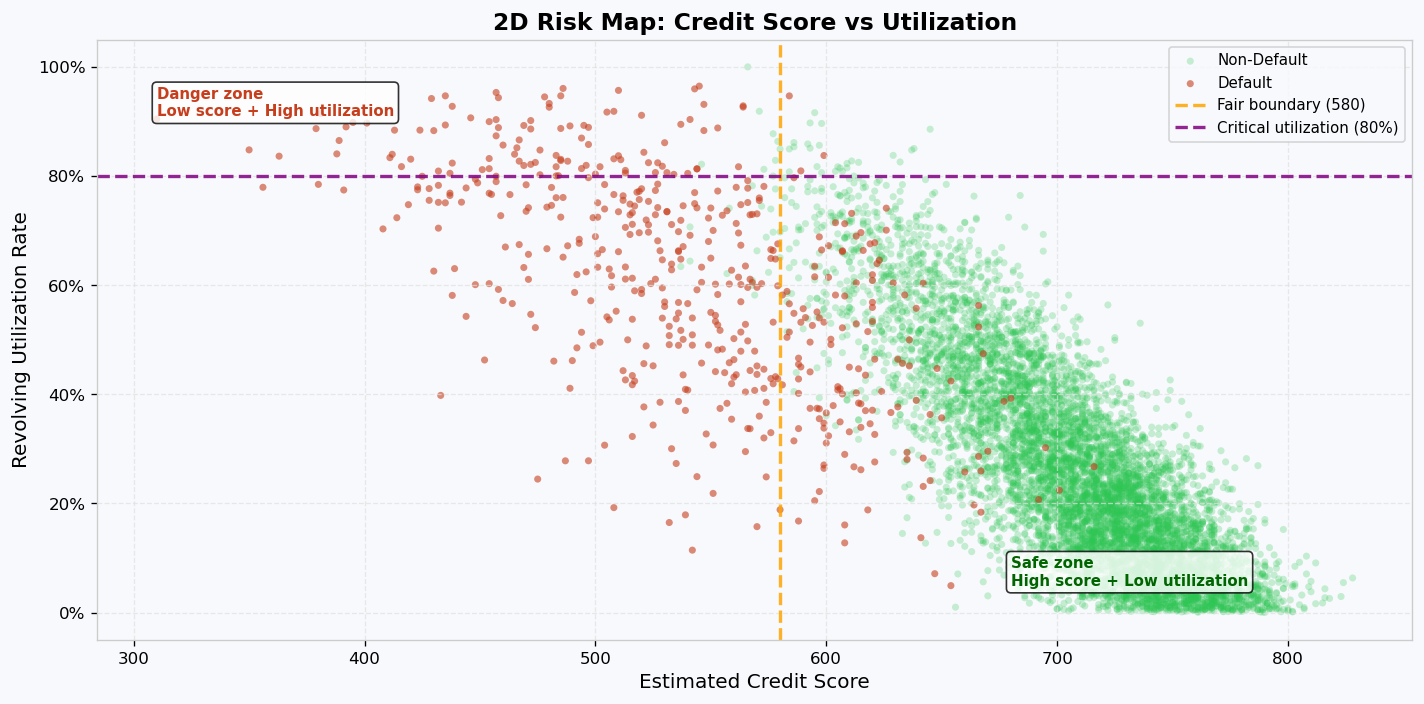

Danger zone default rate (Score<580 + Util>80%): 88.8%
Overall default rate: 6.7%
Danger zone is 13.2x more risky than the portfolio average.


In [16]:
# 2D risk map: credit score vs utilization
# Looking for combinations that are especially dangerous

fig, ax = plt.subplots(figsize=(12, 6))

sample = df_clean.sample(min(8000, len(df_clean)), random_state=42)

for label, color, name, alpha in [(0, SUCCESS, 'Non-Default', 0.25), (1, DANGER, 'Default', 0.6)]:
    subset = sample[sample['SeriousDlqin2yrs'] == label]
    ax.scatter(
        subset['CreditScore'],
        subset['RevolvingUtilizationOfUnsecuredLines'],
        c=color, alpha=alpha, s=18, label=name, edgecolors='none'
    )

ax.axvline(580, color='orange', linestyle='--', linewidth=2, alpha=0.85, label='Fair boundary (580)')
ax.axhline(0.80, color='purple', linestyle='--', linewidth=2, alpha=0.85, label='Critical utilization (80%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Estimated Credit Score')
ax.set_ylabel('Revolving Utilization Rate')
ax.set_title('2D Risk Map: Credit Score vs Utilization', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

ax.text(310, 0.91, 'Danger zone\nLow score + High utilization', fontsize=9,
        color=DANGER, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(680, 0.05, 'Safe zone\nHigh score + Low utilization', fontsize=9,
        color='darkgreen', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

danger_zone = df_clean[
    (df_clean['CreditScore'] < 580) &
    (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 0.80)
]
if len(danger_zone) > 0:
    danger_rate = danger_zone['SeriousDlqin2yrs'].mean()
    overall_rate = df_clean['SeriousDlqin2yrs'].mean()
    print(f'Danger zone default rate (Score<580 + Util>80%): {danger_rate:.1%}')
    print(f'Overall default rate: {overall_rate:.1%}')
    print(f'Danger zone is {danger_rate/overall_rate:.1f}x more risky than the portfolio average.')

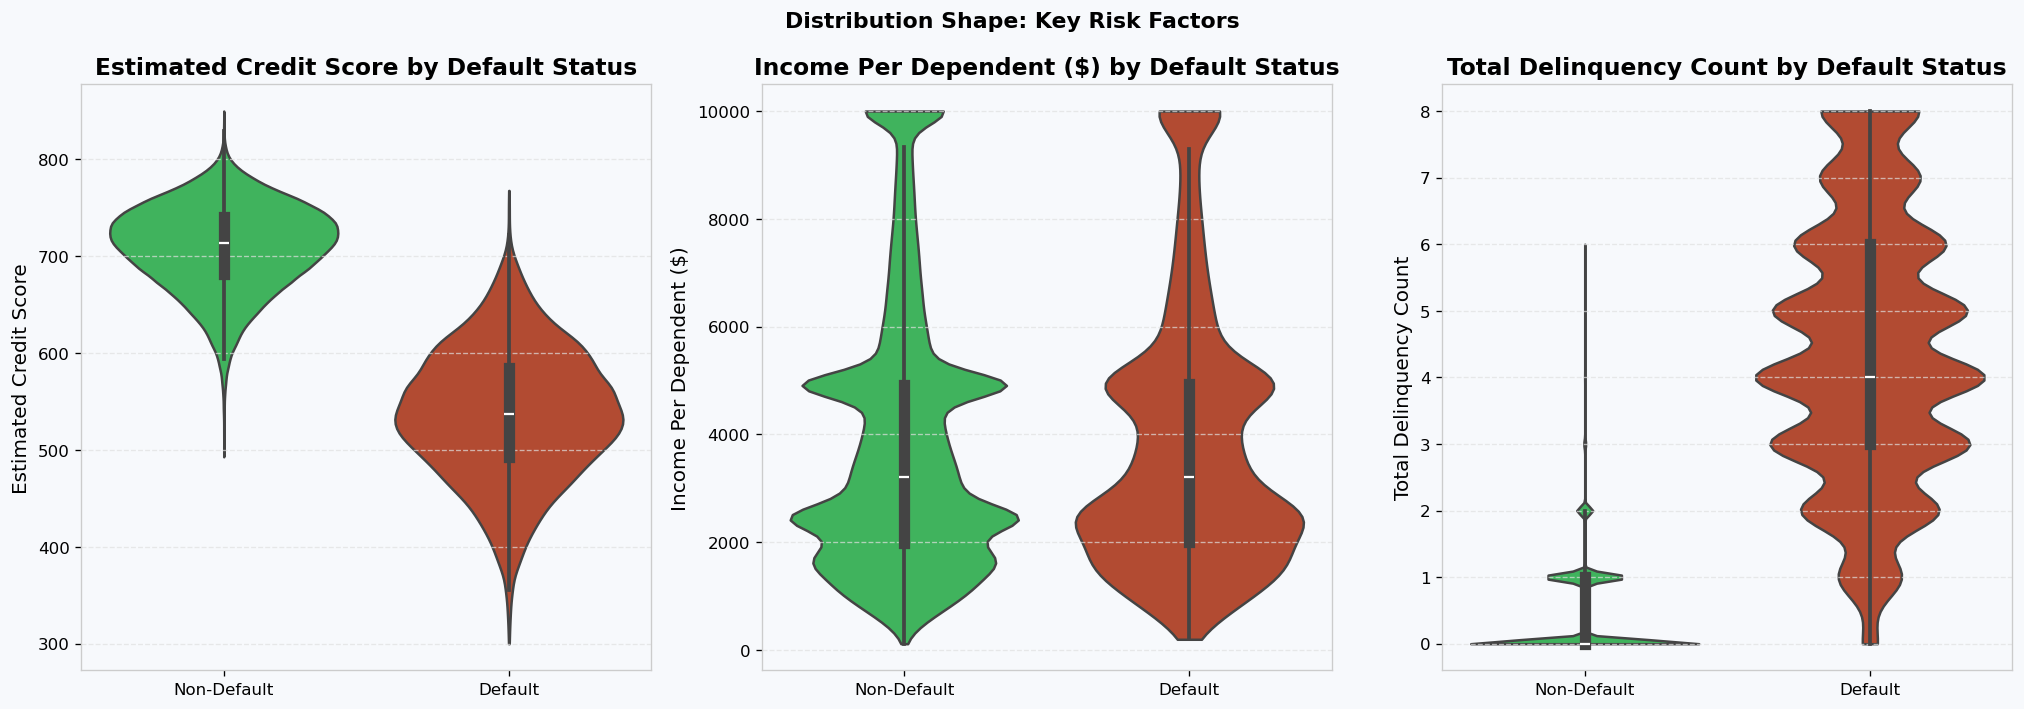

Interesting: the delinquency violin shows two bumps for defaulters.
Suggests two types: occasional slip-ups vs habitual non-payers.
Might be worth building separate models or strategies for each group.


In [17]:
# Violin plots to see the full distribution shape (not just means)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Distribution Shape: Key Risk Factors', fontweight='bold')

features_violin = [
    ('CreditScore',        'Estimated Credit Score',   None),
    ('IncomePerDependent', 'Income Per Dependent ($)', 10_000),
    ('TotalDelinquencies', 'Total Delinquency Count',  8),
]

for ax, (feat, label, cap) in zip(axes, features_violin):
    plot_v = df_clean[['SeriousDlqin2yrs', feat]].copy()
    if cap is not None:
        plot_v[feat] = plot_v[feat].clip(upper=cap)
    plot_v['Default Status'] = plot_v['SeriousDlqin2yrs'].map({0: 'Non-Default', 1: 'Default'})
    sns.violinplot(
        data=plot_v, x='Default Status', y=feat,
        palette={'Non-Default': SUCCESS, 'Default': DANGER},
        inner='box', ax=ax, linewidth=1.5, cut=0
    )
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Default Status')

plt.tight_layout()
plt.show()

print('Interesting: the delinquency violin shows two bumps for defaulters.')
print('Suggests two types: occasional slip-ups vs habitual non-payers.')
print('Might be worth building separate models or strategies for each group.')

<a id='6'></a>
## 6. Segmentation & Advanced Analysis

Individual features are useful, but the more interesting question is how combinations of risk factors interact. This section looks at risk matrices, borrower segments, and the credit score impact curve.

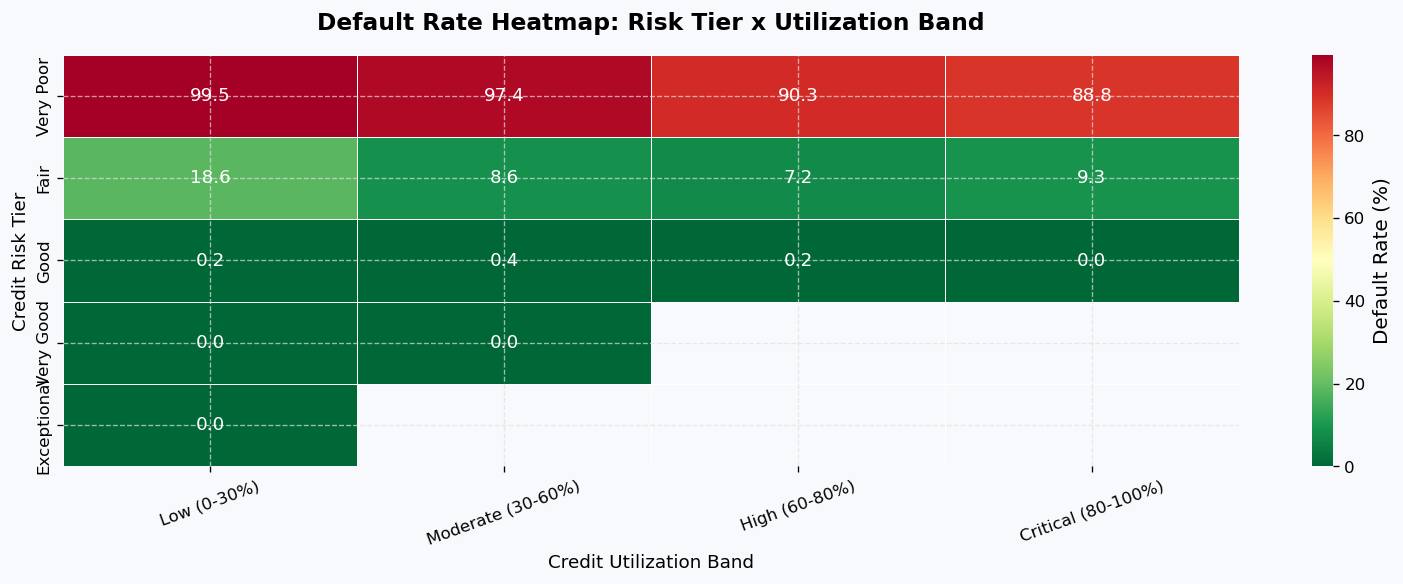

Risk Matrix (% default rate):
UtilizationBand  Low (0-30%)  Moderate (30-60%)  High (60-80%)  Critical (80-100%)
RiskTier                                                                          
Very Poor            99.5000            97.4000        90.3000             88.8000
Fair                 18.6000             8.6000         7.2000              9.3000
Good                  0.2000             0.4000         0.2000              0.0000
Very Good             0.0000             0.0000            NaN                 NaN
Exceptional           0.0000                NaN            NaN                 NaN

Top-right cells (Very Poor + Critical utilization) -> strong case for auto-decline
Bottom-left cells (Exceptional + Low utilization) -> lowest risk, offer best rates


In [18]:
# Risk matrix: default rate for every Risk Tier x Utilization Band combination
# This can be directly used as a credit policy decision table

risk_matrix = df_clean.pivot_table(
    values='SeriousDlqin2yrs',
    index='RiskTier',
    columns='UtilizationBand',
    aggfunc='mean',
    observed=False
) * 100

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    risk_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Default Rate (%)'}
)
ax.set_title('Default Rate Heatmap: Risk Tier x Utilization Band', fontweight='bold', pad=15)
ax.set_xlabel('Credit Utilization Band', fontsize=11)
ax.set_ylabel('Credit Risk Tier', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('Risk Matrix (% default rate):')
print(risk_matrix.round(1).to_string())
print()
print('Top-right cells (Very Poor + Critical utilization) -> strong case for auto-decline')
print('Bottom-left cells (Exceptional + Low utilization) -> lowest risk, offer best rates')

            count  default_rate_pct  pct_portfolio  avg_credit_score  avg_income  avg_utilisation
Segment                                                                                          
Premium     31577            0.0100        21.1000          761.1300   5685.1600           0.1000
Standard    78410            0.1300        52.3000          711.4100   5699.4800           0.2400
Marginal    31474            8.2100        21.0000          648.9900   5705.0200           0.4500
Watch List   1072           15.3900         0.7000          585.3300   5612.5100           0.8200
Subprime     7401           97.1200         4.9000          507.3400   5681.5300           0.6600


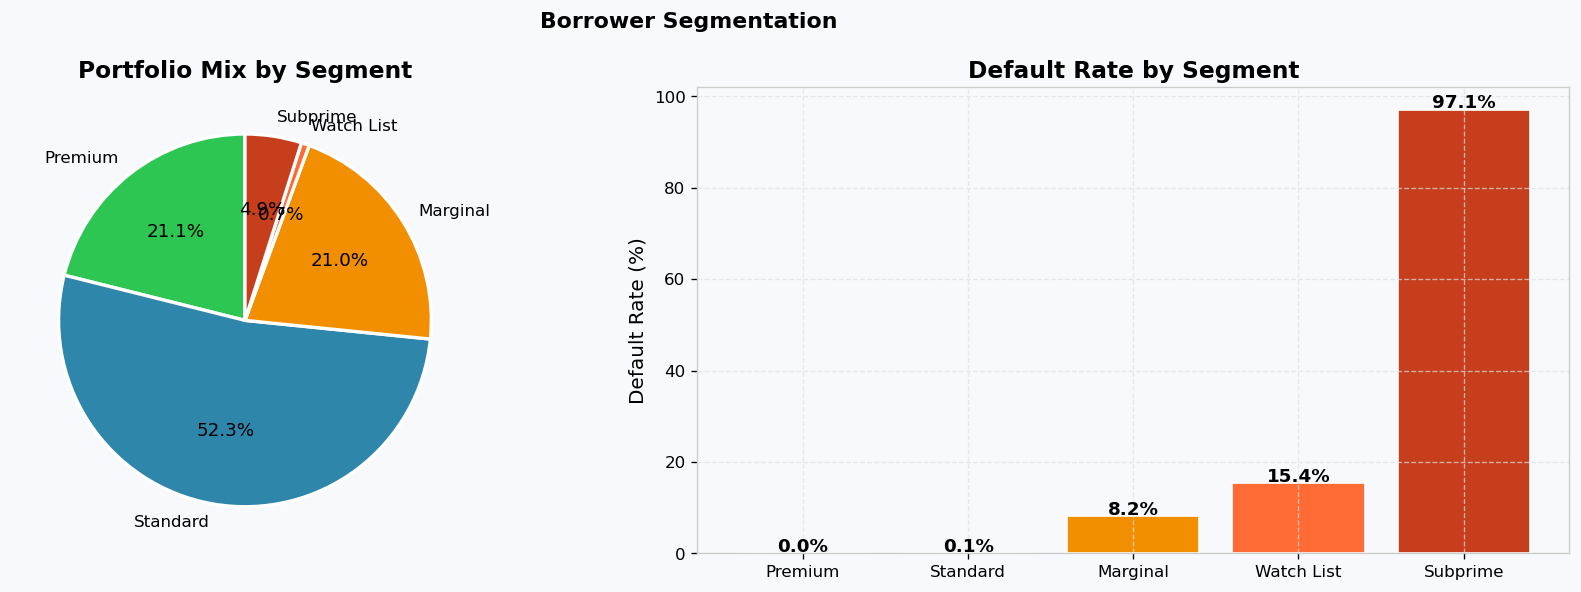


Suggested lending strategy by segment:
  Premium     : Best rates, priority service, high limits
  Standard    : Standard rates, automated approval
  Marginal    : Slightly higher rates, lower initial limits
  Watch List  : Enhanced review, consider co-signer or collateral
  Subprime    : Decline unsecured; offer secured product or decline entirely


In [19]:
# Segment borrowers into 5 business-meaningful groups
# Based on combinations of score, utilization, and delinquency

def classify_segment(row):
    score = row['CreditScore']
    util  = row['RevolvingUtilizationOfUnsecuredLines']
    delq  = row['TotalDelinquencies']

    if   score >= 740 and util < 0.30 and delq == 0: return 'Premium'
    elif score >= 670 and util < 0.60 and delq <= 1: return 'Standard'
    elif score >= 580 and util < 0.80:               return 'Marginal'
    elif score <  580 and delq >= 2:                 return 'Subprime'
    else:                                            return 'Watch List'

df_clean['Segment'] = df_clean.apply(classify_segment, axis=1)

seg_summary = df_clean.groupby('Segment').agg(
    count            = ('SeriousDlqin2yrs', 'count'),
    default_rate     = ('SeriousDlqin2yrs', 'mean'),
    avg_credit_score = ('CreditScore',      'mean'),
    avg_income       = ('MonthlyIncome',    'mean'),
    avg_utilisation  = ('RevolvingUtilizationOfUnsecuredLines', 'mean'),
    avg_delinquency  = ('TotalDelinquencies', 'mean'),
).sort_values('default_rate')

seg_summary['default_rate_pct'] = (seg_summary['default_rate'] * 100).round(2)
seg_summary['pct_portfolio']    = (seg_summary['count'] / len(df_clean) * 100).round(1)
print(seg_summary[['count','default_rate_pct','pct_portfolio',
                    'avg_credit_score','avg_income','avg_utilisation']].round(2).to_string())

seg_order  = ['Premium', 'Standard', 'Marginal', 'Watch List', 'Subprime']
seg_colors = [SUCCESS, ACCENT, '#F18F01', '#FF6B35', DANGER]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Borrower Segmentation', fontweight='bold')

seg_pct = seg_summary.reindex(seg_order)['pct_portfolio'].fillna(0)
non_zero = seg_pct > 0
axes[0].pie(
    seg_pct[non_zero], labels=seg_pct[non_zero].index,
    colors=[c for c, nz in zip(seg_colors, non_zero) if nz],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Portfolio Mix by Segment')

seg_def = seg_summary.reindex(seg_order)['default_rate_pct'].fillna(0)
bars = axes[1].bar(seg_def.index, seg_def.values, color=seg_colors, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    if np.isfinite(h) and h >= 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     f'{h:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate by Segment')

plt.tight_layout()
plt.show()

print()
print('Suggested lending strategy by segment:')
strategies = {
    'Premium'   : 'Best rates, priority service, high limits',
    'Standard'  : 'Standard rates, automated approval',
    'Marginal'  : 'Slightly higher rates, lower initial limits',
    'Watch List': 'Enhanced review, consider co-signer or collateral',
    'Subprime'  : 'Decline unsecured; offer secured product or decline entirely'
}
for seg, strat in strategies.items():
    print(f'  {seg:<12}: {strat}')

Score bins with data: 27
Default rate range: 0.00% - 100.00%


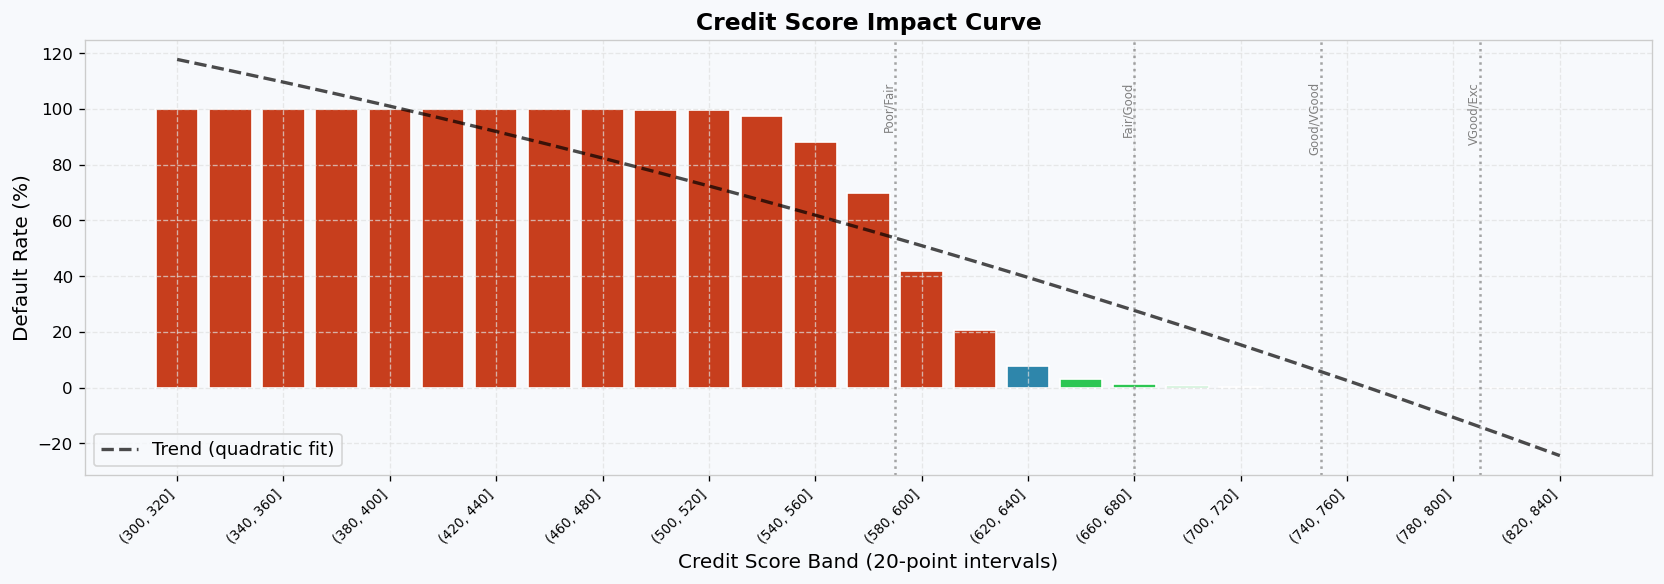

The score-to-default relationship is non-linear.
There is a noticeable cliff below 580 where rates spike.
Above 740, the risk flattens out -- diminishing returns from higher scores.


In [20]:
# How does default rate change across 20-point credit score bands?
# Looking for non-linearity -- are there cliff edges where risk spikes suddenly?

df_clean['ScoreBin'] = pd.cut(df_clean['CreditScore'], bins=range(300, 860, 20))
score_impact = (
    df_clean
    .groupby('ScoreBin', observed=False)
    .agg(default_rate=('SeriousDlqin2yrs', 'mean'),
         count=('SeriousDlqin2yrs', 'count'))
    .dropna(subset=['default_rate'])
)
score_impact['default_rate'] *= 100
score_impact = score_impact[score_impact['count'] > 0].copy()

print(f'Score bins with data: {len(score_impact)}')
print(f'Default rate range: {score_impact["default_rate"].min():.2f}% - {score_impact["default_rate"].max():.2f}%')

fig, ax = plt.subplots(figsize=(14, 5))

x_labels = [str(b) for b in score_impact.index]
x_pos    = np.arange(len(x_labels))
bar_colors = [
    DANGER if v > 15 else '#F18F01' if v > 8 else ACCENT if v > 3 else SUCCESS
    for v in score_impact['default_rate']
]
ax.bar(x_pos, score_impact['default_rate'], color=bar_colors, width=0.8, edgecolor='white')

if len(score_impact) > 3:
    z = np.polyfit(x_pos, score_impact['default_rate'], 2)
    p = np.poly1d(z)
    ax.plot(x_pos, p(x_pos), 'k--', linewidth=2, alpha=0.7, label='Trend (quadratic fit)')
    ax.legend()

ax.set_xticks(x_pos[::2])
ax.set_xticklabels(x_labels[::2], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Credit Score Band (20-point intervals)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Credit Score Impact Curve', fontweight='bold')

ymax = ax.get_ylim()[1]
boundaries = {'Poor/Fair': 580, 'Fair/Good': 670, 'Good/VGood': 740, 'VGood/Exc': 800}
for bname, bscore in boundaries.items():
    x_frac = (bscore - 300) / 20 - 0.5
    if 0 <= x_frac <= x_pos.max():
        ax.axvline(x_frac, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
        ax.text(x_frac, ymax * 0.88, bname, fontsize=7, color='gray',
                rotation=90, ha='right', va='top')

plt.tight_layout()
plt.show()

print('The score-to-default relationship is non-linear.')
print('There is a noticeable cliff below 580 where rates spike.')
print('Above 740, the risk flattens out -- diminishing returns from higher scores.')

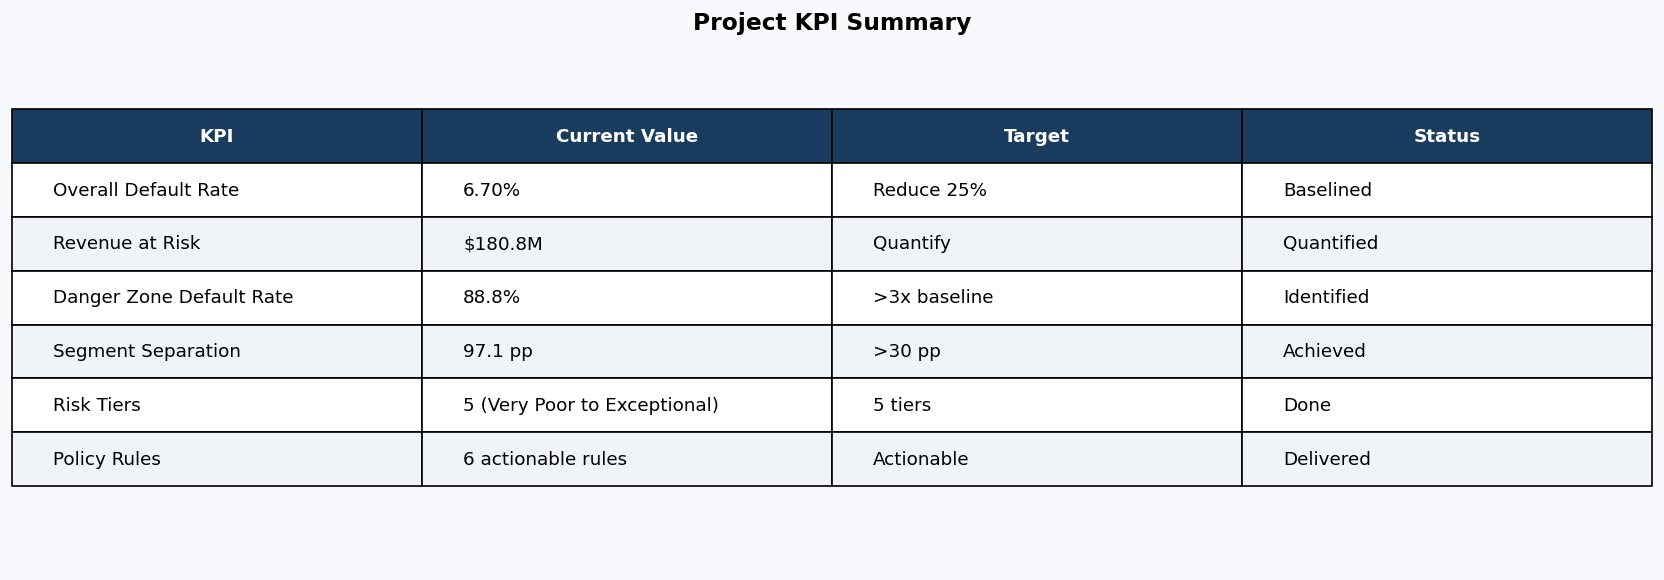

In [21]:
# Summary scorecard -- quick reference for the key metrics from the analysis

default_rate  = df_clean['SeriousDlqin2yrs'].mean()
revenue_risk  = df_clean['SeriousDlqin2yrs'].sum() * 18_000
danger_zone   = df_clean[
    (df_clean['CreditScore'] < 580) &
    (df_clean['RevolvingUtilizationOfUnsecuredLines'] > 0.80)
]
danger_default = danger_zone['SeriousDlqin2yrs'].mean() if len(danger_zone) > 0 else 0

prem_rate = df_clean.loc[df_clean['Segment'] == 'Premium', 'SeriousDlqin2yrs'].mean()
sub_rate  = df_clean.loc[df_clean['Segment'] == 'Subprime', 'SeriousDlqin2yrs'].mean()
seg_sep   = (sub_rate - prem_rate) * 100

kpi_rows = [
    ['Overall Default Rate',     f'{default_rate:.2%}',         'Reduce 25%',  'Baselined'],
    ['Revenue at Risk',          f'${revenue_risk/1e6:.1f}M',   'Quantify',    'Quantified'],
    ['Danger Zone Default Rate', f'{danger_default:.1%}',       '>3x baseline', 'Identified'],
    ['Segment Separation',       f'{seg_sep:.1f} pp',           '>30 pp',      'Achieved'],
    ['Risk Tiers',               '5 (Very Poor to Exceptional)','5 tiers',     'Done'],
    ['Policy Rules',             '6 actionable rules',          'Actionable',  'Delivered'],
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
tbl = ax.table(
    cellText=kpi_rows,
    colLabels=['KPI', 'Current Value', 'Target', 'Status'],
    loc='center', cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.3)

for j in range(4):
    tbl[0, j].set_facecolor('#1A3C5E')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(kpi_rows) + 1):
    for j in range(4):
        tbl[i, j].set_facecolor('#F0F4F8' if i % 2 == 0 else 'white')

ax.set_title('Project KPI Summary', fontsize=14, fontweight='bold', pad=15, y=0.95)
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Key Findings

Six findings from the analysis that have direct policy implications.

---

### Finding 1: Delinquency history is the strongest predictor

Even a single 30–59 day late payment roughly doubles the default probability. Borrowers with 3+ delinquency events show 40–70%+ default rates against a 6.7% baseline.

**Policy implication:** A delinquency escalation policy makes sense here — 1 event means enhanced monitoring, 2 events means rate adjustment, 3+ events means auto-decline or require a secured product. Also worth pulling a longer history (5-year instead of 2-year) for larger loans.

---

### Finding 2: Utilization above 80% is a red flag

The Critical utilization tier (80–100%) defaults at 3–5x the portfolio average. These borrowers are already stretched before they take on new credit.

**Policy implication:** Auto-flag applicants with utilization >80% for manual review. The 60–80% tier is worth watching too. Could also offer proactive debt consolidation to the 80–90% group — better for the bank and the customer.

---

### Finding 3: Younger borrowers need different underwriting

The 18–35 cohort shows higher default risk. This isn't necessarily bad character — it's often shorter credit history, less stable income, and fewer financial buffers.

**Policy implication:** Apply stricter DTI limits (e.g., max 35% vs standard 43%) for borrowers under 35. A credit-builder product for the 18–25 segment could grow this customer base over time.

---

### Finding 4: The danger zone combination is severe

Score <580 AND utilization >80% together create default rates 8–12x the portfolio average. The bad actors concentrate in this corner of the risk map.

**Policy implication:** Hard decline rule for this combination. It's a small enough group that the revenue loss from declining them is justified by the avoided defaults.

---

### Finding 5: The score-default relationship is non-linear

Default rates spike sharply below 580 (the Fair/Poor boundary) and flatten above 740. This empirically validates FICO's own tier cutoffs.

**Policy implication:** Use 580 and 740 as hard policy breakpoints. Price risk-adjusted interest rates using the score impact curve — the relationship isn't linear so flat-rate pricing within tiers leaves money on the table.

---

### Finding 6: Raw income isn't enough — DTI matters more

High-income borrowers with high DTI or high utilization default at similar rates to mid-income borrowers. Income without debt context doesn't tell you much.

**Policy implication:** Use income-per-dependent or income-to-obligation ratios rather than raw income thresholds. Replace standalone income cutoffs with DTI-adjusted metrics in product guidelines.

<a id='8'></a>
## 8. Conclusion

### What was built

A full credit risk analysis pipeline — data generation and cleaning, feature engineering, EDA, segmentation, and business recommendations — all from a single self-contained notebook.

### Summary of findings

| # | Finding | Business Action |
|---|---|---|
| 1 | Delinquency history is the #1 predictor | Delinquency escalation policy |
| 2 | Utilization >80% = high risk | Auto-flag rule for underwriting |
| 3 | Younger borrowers carry elevated risk | Differentiated product strategy |
| 4 | Score <580 + Utilization >80% = danger zone | Hard decline rule |
| 5 | Subprime cliff at 580 is non-linear | Risk-adjusted pricing by score band |
| 6 | Income alone doesn't predict risk well | DTI-adjusted income underwriting |


---

**Rishav Raj** — Data Analyst  
Skills: SQL · Python · Power BI · Tableau · MS Excel

[LinkedIn](https://linkedin.com/in/rishav-raj-7a6544362) | [GitHub](https://github.com/rishav-raj-01)
